# Análisis de reseñas de Trustpilot

## Objetivo

El objetivo de este proyecto es analizar las reseñas de una empresa del dataset de Trustpilot utilizando técnicas de NLP para:

- Evaluar el sentimiento de los clientes
- Identificar los principales temas (topics) en las reseñas
- Analizar el sentimiento asociado a cada tema
- Detectar fortalezas y áreas de mejora

La empresa seleccionada es **Airtime Rewards**, perteneciente al sector de Money & Insurance.

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Carga de datos

Se cargan los datasets proporcionados:
- Reseñas de Trustpilot
- Empresas con 100 reviews

Se selecciona una empresa concreta para el análisis.

In [60]:
df = pd.read_csv("../data/raw/trustpilot-reviews-123k.csv")
empresas = pd.read_excel("../data/raw/emp_100_reviews.xlsx")

In [61]:
print(df.shape)
print(empresas.shape)

df.head()

(123181, 6)
(558, 6)


,category,company,description,title,review,stars
0,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Great quality dog drying robe although…,Great quality dog drying robe although had to ...,5
1,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Really prompt service,"Really prompt service, The sofa covers have no...",5
2,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Life saver,I’ve purchased first of those coats in May2020...,5
3,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Brilliant coats,Brilliant coats. Really like the limited editi...,5
4,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Great company and products,Great company and products. This is my 3rd dry...,5


In [62]:
print(df.columns.tolist())
print(empresas.columns.tolist())

['category', 'company', 'description', 'title', 'review', 'stars']
['category', 'company', 'n_reviews', 'median_stars', 'media_stars', 'std_stars']


In [63]:
empresas.head(20)

,category,company,n_reviews,median_stars,media_stars,std_stars
0,Animals & Pets,gardenbird.co.uk,100,3,3,1.421338
1,Restaurants & Bars,www.brewersfayre.co.uk,100,3,3,1.421338
2,Restaurants & Bars,mindfulchef.com,100,3,3,1.421338
3,Restaurants & Bars,nonnatonda.co.uk,100,3,3,1.421338
4,Restaurants & Bars,planthood.co.uk,100,3,3,1.421338
5,Restaurants & Bars,simplycook.com,100,3,3,1.421338
6,Restaurants & Bars,thecornishfishmonger.co.uk,100,3,3,1.421338
7,Restaurants & Bars,wetherspoons.co.uk,100,3,3,1.421338
8,Restaurants & Bars,www.burgerking.co.uk,100,3,3,1.421338
9,Restaurants & Bars,www.oddbox.co.uk,100,3,3,1.421338


In [64]:
conteo_reviews = (
    df[df["company"].isin(empresas["company"])]
    .groupby("company")
    .size()
    .reset_index(name="n_reviews_csv")
    .sort_values("n_reviews_csv", ascending=False)
)

conteo_reviews.head(20)

,company,n_reviews_csv
0,1stchoice.co.uk,100
1,360.optimalegal.co.uk,100
2,airtimerewards.co.uk,100
3,allbeauty.com,100
4,amawaste.co.uk,100
5,anchorpumps.com,100
6,anyjunk.co.uk,100
7,arbolus.com,100
8,ariston.com,100
9,ascenti.co.uk,100


## Exploración de datos

Se analiza la distribución de reseñas y se selecciona una empresa con:

- Distribución equilibrada de estrellas
- Variedad de opiniones
- Sector con potencial analítico

In [65]:
stats_empresas = (
    df[df["company"].isin(empresas["company"])]
    .groupby("company")
    .agg(
        n_reviews=("stars", "count"),
        media_stars=("stars", "mean"),
        std_stars=("stars", "std"),
        min_stars=("stars", "min"),
        max_stars=("stars", "max")
    )
    .reset_index()
    .sort_values(["std_stars", "n_reviews"], ascending=[False, False])
)

stats_empresas.head(20)

,company,n_reviews,media_stars,std_stars,min_stars,max_stars
0,1stchoice.co.uk,100,3.0,1.421338,1,5
1,360.optimalegal.co.uk,100,3.0,1.421338,1,5
2,airtimerewards.co.uk,100,3.0,1.421338,1,5
3,allbeauty.com,100,3.0,1.421338,1,5
4,amawaste.co.uk,100,3.0,1.421338,1,5
5,anchorpumps.com,100,3.0,1.421338,1,5
6,anyjunk.co.uk,100,3.0,1.421338,1,5
7,arbolus.com,100,3.0,1.421338,1,5
8,ariston.com,100,3.0,1.421338,1,5
9,ascenti.co.uk,100,3.0,1.421338,1,5


In [66]:
sector_empresa = (
    df[["company", "category"]]
    .drop_duplicates()
)

candidatas = stats_empresas.merge(sector_empresa, on="company", how="left")
candidatas.head(20)

,company,n_reviews,media_stars,std_stars,min_stars,max_stars,category
0,1stchoice.co.uk,100,3.0,1.421338,1,5,Vehicles & Transportation
1,360.optimalegal.co.uk,100,3.0,1.421338,1,5,Legal Services & Government
2,airtimerewards.co.uk,100,3.0,1.421338,1,5,Money & Insurance
3,allbeauty.com,100,3.0,1.421338,1,5,Beauty & Well-being
4,amawaste.co.uk,100,3.0,1.421338,1,5,Home Services
5,anchorpumps.com,100,3.0,1.421338,1,5,Construction & Manufacturing
6,anyjunk.co.uk,100,3.0,1.421338,1,5,Public & Local Services
7,arbolus.com,100,3.0,1.421338,1,5,Public & Local Services
8,ariston.com,100,3.0,1.421338,1,5,Construction & Manufacturing
9,ascenti.co.uk,100,3.0,1.421338,1,5,Health & Medical


In [67]:
top_candidatas = candidatas.head(10)["company"].tolist()

for empresa in top_candidatas:
    print(f"\nEmpresa: {empresa}")
    print(df[df["company"] == empresa]["stars"].value_counts().sort_index())


Empresa: 1stchoice.co.uk
stars
1    20
2    20
3    20
4    20
5    20
Name: count, dtype: int64

Empresa: 360.optimalegal.co.uk
stars
1    20
2    20
3    20
4    20
5    20
Name: count, dtype: int64

Empresa: airtimerewards.co.uk
stars
1    20
2    20
3    20
4    20
5    20
Name: count, dtype: int64

Empresa: allbeauty.com
stars
1    20
2    20
3    20
4    20
5    20
Name: count, dtype: int64

Empresa: amawaste.co.uk
stars
1    20
2    20
3    20
4    20
5    20
Name: count, dtype: int64

Empresa: anchorpumps.com
stars
1    20
2    20
3    20
4    20
5    20
Name: count, dtype: int64

Empresa: anyjunk.co.uk
stars
1    20
2    20
3    20
4    20
5    20
Name: count, dtype: int64

Empresa: arbolus.com
stars
1    20
2    20
3    20
4    20
5    20
Name: count, dtype: int64

Empresa: ariston.com
stars
1    20
2    20
3    20
4    20
5    20
Name: count, dtype: int64

Empresa: ascenti.co.uk
stars
1    20
2    20
3    20
4    20
5    20
Name: count, dtype: int64


In [68]:
df_empresa = df[df["company"] == "airtimerewards.co.uk"]

df_empresa["stars"].value_counts().sort_index()

stars
1    20
2    20
3    20
4    20
5    20
Name: count, dtype: int64

In [69]:
df_empresa["review"].head(5)

58565    Easy to make a purchase and get airtime credit...
58566    100% recommend to anyone it saves a fortune of...
58567    Like it as no effort to earn money.done need t...
58568    A wonderful platform. It allows me to earn cas...
58569    Great way to benefit from everyday spending an...
Name: review, dtype: object

## Preprocesamiento de texto

Se realiza limpieza del texto para preparar los datos para el análisis:

- Conversión a minúsculas
- Eliminación de caracteres especiales
- Eliminación de stopwords
- Lematización

Este paso es clave para mejorar la calidad de los modelos NLP.

In [70]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def limpiar_texto(texto):
    if pd.isna(texto):
        return ""
    texto = texto.lower()
    texto = re.sub(r"[^a-zA-Z\s]", " ", texto)
    palabras = texto.split()
    palabras = [w for w in palabras if w not in stop_words]
    palabras = [lemmatizer.lemmatize(w) for w in palabras]
    return " ".join(palabras)

df_empresa = df[df["company"] == "airtimerewards.co.uk"].copy()

df_empresa.loc[:, "clean_review"] = df_empresa["review"].apply(limpiar_texto)
df_empresa.loc[:, "sentimiento"] = df_empresa["stars"].apply(
    lambda x: "positivo" if x >= 4 else "negativo"
)

print(df_empresa["clean_review"].isna().sum())
df_empresa[["review", "clean_review", "sentimiento"]].head()

0


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\pepetorres\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\pepetorres\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,review,clean_review,sentimiento
58565,Easy to make a purchase and get airtime credit...,easy make purchase get airtime credit account ...,positivo
58566,100% recommend to anyone it saves a fortune of...,recommend anyone save fortune phone bill save ...,positivo
58567,Like it as no effort to earn money.done need t...,like effort earn money done need activate offe...,positivo
58568,A wonderful platform. It allows me to earn cas...,wonderful platform allows earn cashbacks purch...,positivo
58569,Great way to benefit from everyday spending an...,great way benefit everyday spending save money...,positivo


## Análisis de sentimiento

Se clasifica cada reseña como positiva o negativa en función de la puntuación (stars).

Resultados:
- 60% de las reseñas son negativas
- 40% son positivas

Esto indica una percepción general negativa de la empresa, aunque con cierta polarización.

In [71]:
df_empresa["sentimiento"].value_counts(normalize=True)

sentimiento
negativo    0.6
positivo    0.4
Name: proportion, dtype: float64

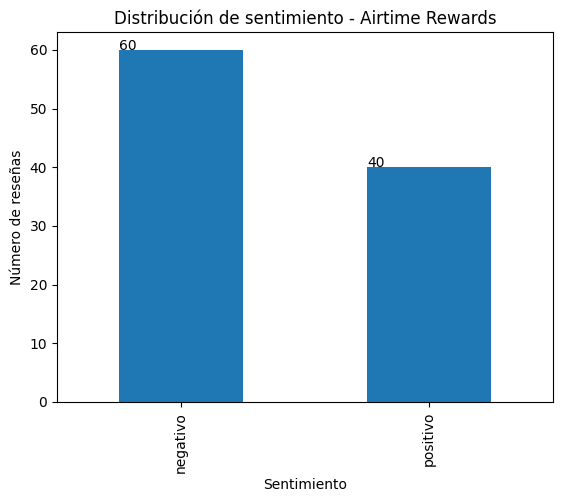

In [72]:
ax = df_empresa["sentimiento"].value_counts().plot(kind="bar")
plt.title("Distribución de sentimiento - Airtime Rewards")
plt.xlabel("Sentimiento")
plt.ylabel("Número de reseñas")

for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x(), p.get_height()))

plt.show()

La mayoría de reseñas son negativas (60%), aunque existe un 40% positivo que indica una experiencia mixta del cliente

In [73]:
df_empresa["clean_review"].isna().sum()

np.int64(0)

## Análisis de topics

Se aplica LDA para identificar los principales temas en las reseñas.

Se identifican los siguientes topics:

- Topic 0: Pagos y recompensas
- Topic 1: Uso del servicio y facturación
- Topic 2: Compras y partners
- Topic 3: Valor y ahorro
- Topic 4: Atención al cliente

In [74]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

vectorizer = CountVectorizer(max_df=0.9, min_df=5)
X = vectorizer.fit_transform(df_empresa["clean_review"])

In [75]:
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",5
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [76]:
words = vectorizer.get_feature_names_out()

for i, topic in enumerate(lda.components_):
    print(f"\nTopic {i}:")
    print([words[i] for i in topic.argsort()[-10:]])


Topic 0:
['account', 'work', 'card', 'purchase', 'one', 'reward', 'get', 'credit', 'airtime', 'transaction']

Topic 1:
['use', 'phone', 'day', 'great', 'missing', 'get', 'bill', 'time', 'easy', 'transaction']

Topic 2:
['app', 'list', 'month', 'money', 'waitrose', 'boot', 'shop', 'back', 'reward', 'retailer']

Topic 3:
['spend', 'back', 'take', 'worth', 'bill', 'saved', 'day', 'month', 'reward', 'money']

Topic 4:
['card', 'service', 'customer', 'redeem', 'app', 'account', 'phone', 'bill', 'airtime', 'reward']


In [77]:
topic_values = lda.transform(X)
df_empresa["topic"] = topic_values.argmax(axis=1)

## Relación entre topics y sentimiento

Se analiza el sentimiento asociado a cada tema.

Principales resultados:

- Pagos y recompensas: mayoritariamente negativo (~81%)
- Valor y ahorro: mayoritariamente negativo (~80%)
- Compras y partners: negativo (~70%)
- Uso del servicio: mixto (50/50)
- Atención al cliente: ligeramente positivo (~51%)

Esto permite identificar los principales problemas del servicio.

In [78]:
pd.crosstab(df_empresa["topic"], df_empresa["sentimiento"], normalize="index")

sentimiento,negativo,positivo
topic,,
0,0.812500,0.187500
1,0.500000,0.500000
2,0.700000,0.300000
3,0.800000,0.200000
4,0.487179,0.512821


## Conclusiones

Los principales problemas de la empresa se encuentran en:

- Fallos en el sistema de recompensas
- Baja percepción de valor por parte del cliente
- Problemas en la interacción con partners comerciales

Como punto positivo, la atención al cliente presenta mejores resultados.

Se recomienda:

- Mejorar la fiabilidad del sistema de cashback
- Alinear expectativas del cliente con la realidad del servicio
- Optimizar la relación con retailers